<a href="https://colab.research.google.com/github/BrunoOrnll/Gitlab/blob/main/git_tab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/openpyxl/packaging/custom.py:213: UserWarning: Unknown type for ESRI_WORKBOOK_ID
  warn(f"Unknown type for {prop.name}")
/usr/local/lib/python3.12/dist-packages/openpyxl/packaging/custom.py:213: UserWarning: Unknown type for ESRI_WORKBOOK_ID
  warn(f"Unknown type for {prop.name}")



--- VALORES NULOS ---
+---+------+---------+----+
|Ano|Obitos|Populacao|Taxa|
+---+------+---------+----+
|  0|     0|        0|   0|
+---+------+---------+----+

--- ESTATÍSTICAS ---
+-----------------+------------------+------------------+------------------+
|     Media_Obitos|     Desvio_Obitos|         Media_Pop|   Media_Taxa_100k|
+-----------------+------------------+------------------+------------------+
|841.6521739130435|158.16378412486105|6303419.0869565215|13.438063828440686|
+-----------------+------------------+------------------+------------------+

+-------+-----------------+------------------+------------------+------------------+
|summary|              Ano|            Obitos|         Populacao|              Taxa|
+-------+-----------------+------------------+------------------+------------------+
|  count|               23|                23|                23|                23|
|   mean|           2011.0| 841.6521739130435|6303419.0869565215|13.438063828440686|
| st

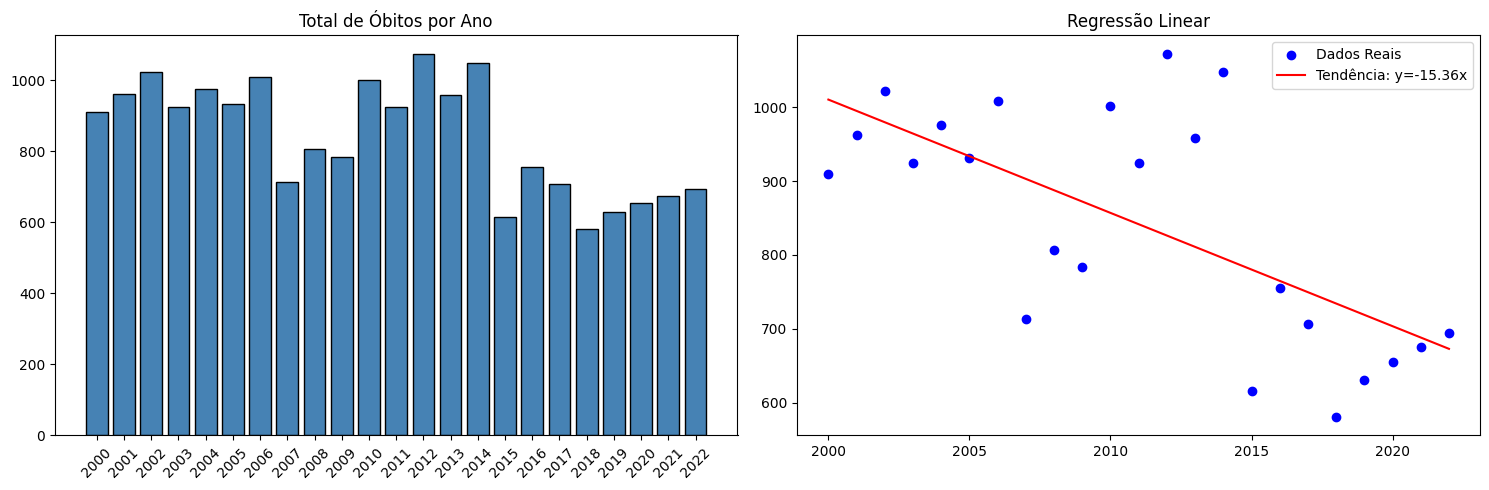

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, mean, stddev

# Funçao auxiliar para remover acentos e padronizar nomes
def normalizar_texto(texto):
    if not isinstance(texto, str):
        return str(texto)

    texto = texto.lower().strip()

    return "".join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def iniciar_projeto():
    return SparkSession.builder.appName("AnaliseMortalidade").getOrCreate()

def processar_dados(caminho):

    # Lê direto do GitHub
    pdf_bruto = pd.read_excel(caminho)

    linha_cabecalho = 0

    for i, linha in pdf_bruto.iterrows():
        valores = [normalizar_texto(v) for v in linha.values]

        if 'ano' in valores:
            linha_cabecalho = i
            break

    pdf = pd.read_excel(caminho, skiprows=linha_cabecalho + 1)

    if 'Ano' not in pdf.columns:
        pdf.columns = pdf_bruto.iloc[linha_cabecalho].values

    cols_originais = pdf.columns
    mapeamento = {}

    for c in cols_originais:
        norm = normalizar_texto(c)

        if 'ano' in norm:
            mapeamento['ano'] = c

        elif 'obito' in norm:
            mapeamento['obitos'] = c

        elif 'popula' in norm:
            mapeamento['populacao'] = c

        elif 'taxa' in norm:
            mapeamento['taxa'] = c

    if 'ano' not in mapeamento or 'obitos' not in mapeamento:
        print("Colunas encontradas:", list(cols_originais))

        raise ValueError(
            "Não foi possível encontrar as colunas de 'Ano' ou 'Óbitos'."
        )

    for chave, nome_real in mapeamento.items():
        pdf[nome_real] = pd.to_numeric(
            pdf[nome_real],
            errors='coerce'
        )

    pdf = pdf.dropna(
        subset=[mapeamento['ano'], mapeamento['obitos']]
    )

    pdf = pdf.sort_values(by=mapeamento['ano'])

    pdf = pdf.rename(columns={
        mapeamento['ano']: 'Ano',
        mapeamento['obitos']: 'Obitos',
        mapeamento['populacao']: 'Populacao',
        mapeamento['taxa']: 'Taxa'
    })

    return pdf[['Ano', 'Obitos', 'Populacao', 'Taxa']]

def realizar_analise_estatistica(spark, pdf):

    df_spark = spark.createDataFrame(pdf)

    print("\n--- VALORES NULOS ---")

    df_spark.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df_spark.columns
    ]).show()

    print("--- ESTATÍSTICAS ---")

    df_spark.select(
        mean("Obitos").alias("Media_Obitos"),
        stddev("Obitos").alias("Desvio_Obitos"),
        mean("Populacao").alias("Media_Pop"),
        mean("Taxa").alias("Media_Taxa_100k")
    ).show()

    df_spark.describe().show()

    return df_spark

def gerar_graficos(pdf):

    x = pdf['Ano'].values
    y = pdf['Obitos'].values

    m, b = np.polyfit(x, y, 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.bar(
        x.astype(int).astype(str),
        y,
        color='steelblue',
        edgecolor='black'
    )

    ax1.set_title('Total de Óbitos por Ano')
    ax1.tick_params(axis='x', rotation=45)

    ax2.scatter(x, y, color='blue', label='Dados Reais')

    ax2.plot(
        x,
        m*x + b,
        color='red',
        label=f'Tendência: y={m:.2f}x'
    )

    ax2.set_title('Regressão Linear')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# EXECUÇÃO PRINCIPAL
try:

    sessao = iniciar_projeto()

    caminho = "https://raw.githubusercontent.com/BrunoOrnll/Gitlab/main/dados_transito.xlsx"

    df_limpo = processar_dados(caminho)

    realizar_analise_estatistica(sessao, df_limpo)

    gerar_graficos(df_limpo)

finally:

    if 'sessao' in locals():
        sessao.stop()